# Deep Learning Demand Forecasting (LSTM)

In Phase 5, we used a traditional statistical model (Prophet). Now, we will implement a state-of-the-art Deep Learning model using a **Long Short-Term Memory (LSTM)** neural network. We will use **PyTorch Lightning** to structure our model professionally.

**Our Goals:**
1. Prepare and scale the weekly revenue data.
2. Transform the data into supervised learning "sequences" (e.g., using the past 4 weeks to predict the 5th week).
3. Build a PyTorch Lightning Module for the LSTM.
4. Train the model and evaluate its performance against our baseline.

**LSTM (Long Short-Term Memory)** is a type of Recurrent Neural Network (RNN) designed to:
- Capture long-term dependencies in sequential data
- Remember patterns over extended time periods
- Handle complex non-linear relationships

**Why LSTM for demand forecasting?**
- Retail demand has weekly/monthly patterns
- LSTM can learn these automatically without manual feature engineering
- Better at capturing complex seasonality than traditional models

In [36]:
# Loading libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import joblib

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl
from pytorch_lightning.loggers import MLFlowLogger

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Set random seed for reproducibility
pl.seed_everything(42)

Seed set to 42


42

## 1. Data Preparation & Scaling
Neural networks are highly sensitive to the scale of input data. We must scale our revenue down to a range between `(-1, 1)` or `(0, 1)` using `MinMaxScaler`.

In [37]:
# Load data and resample to weekly revenue
df = pd.read_csv('../data/processed/online_retail_initial.csv', usecols=['InvoiceDate', 'TotalPrice'])
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Date'] = df['InvoiceDate'].dt.date

daily_revenue = df.groupby('Date')['TotalPrice'].sum().reset_index()
daily_revenue['Date'] = pd.to_datetime(daily_revenue['Date'])
daily_revenue.set_index('Date', inplace=True)

weekly_revenue = daily_revenue.resample('W').sum().reset_index()

# Isolate the target variable
data = weekly_revenue[['TotalPrice']].values.astype('float32')

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

print(f"Total weeks of data: {len(data_scaled)}")

Total weeks of data: 106


## 2. Creating Sequences (Sliding Window)
To train an LSTM, we need to convert our single column of data into pairs of `(X, y)`.
- `X` will be a sequence of $N$ previous weeks.
- `y` will be the revenue of the $N+1$ week.

In [38]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

SEQUENCE_LENGTH = 8 # Use the past 8 weeks (2 months) to predict the next week
X, y = create_sequences(data_scaled, SEQUENCE_LENGTH)

# (batch_size, sequence_length, num_features)
print(f"X shape: {X.shape}") 
print(f"y shape: {y.shape}")

X shape: (98, 8, 1)
y shape: (98, 1)


### Train/Test Split & PyTorch DataLoaders
We split off the last 12 weeks for testing (just like in our Prophet model).

In [39]:
TEST_SIZE = 12

X_train, y_train = X[:-TEST_SIZE], y[:-TEST_SIZE]
X_test, y_test = X[-TEST_SIZE:], y[-TEST_SIZE:]

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# PyTorch DataLoaders
train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

## 3. PyTorch Lightning LSTM Module
We encapsulate our neural network architecture, training loop, and optimizer inside a clean `LightningModule`.

In [40]:
class LSTMForecaster(pl.LightningModule):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2, output_dim=1, learning_rate=0.001):
        super().__init__()
        self.save_hyperparameters()
        
        # LSTM Layer
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        
        # The Output fully-connected layer
        self.linear = nn.Linear(hidden_dim, output_dim)
        
        self.loss_fn = nn.MSELoss()
        
    def forward(self, x):
        # x shape: (batch, seq_len, input_dim)
        lstm_out, (hn, cn) = self.lstm(x)
        last_time_step_out = lstm_out[:, -1, :]
        out = self.linear(last_time_step_out)
        return out
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.loss_fn(y_hat, y)
        self.log('train_loss', loss, prog_bar=True)
        return loss
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)

## 4. Training the Model
We use the PyTorch Lightning `Trainer` which abstracts away all the complex training loops.

In [41]:
# Initialize model
model = LSTMForecaster(hidden_dim=128, num_layers=2, learning_rate=0.005)

# Initialize trainer
trainer = pl.Trainer(max_epochs=150, enable_progress_bar=True, enable_model_summary=False, logger=False)
trainer.fit(model, train_loader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`Trainer.fit` stopped: `max_epochs=150` reached.


## 5. Forecasting & Evaluation
Now we pass our unseen Test Set through the trained network, inverse transform the scaled predictions back to actual Revenue (£), and calculate our error metrics.

In [42]:
model.eval()
predictions_scaled = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        y_hat = model(x_batch)
        predictions_scaled.append(y_hat.numpy().flatten()[0])

# Inverse transform the predictions and actuals back to original £ values
predictions = scaler.inverse_transform(np.array(predictions_scaled).reshape(-1, 1))
actuals = scaler.inverse_transform(y_test)

# Error Metrics
mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))
mape = np.mean(np.abs((actuals - predictions) / (actuals + 1e-9))) * 100
mean_revenue = actuals.mean()

print(f"--- LSTM Evaluation (12-Week Forecast) ---")
print(f"Mean Absolute Error (MAE): £{mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): £{rmse:,.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:,.2f}%")
print(f"Average Weekly Revenue in Test Set: £{mean_revenue:,.2f}")

--- LSTM Evaluation (12-Week Forecast) ---
Mean Absolute Error (MAE): £62,732.64
Root Mean Squared Error (RMSE): £72,326.59
Mean Absolute Percentage Error (MAPE): 22.09%
Average Weekly Revenue in Test Set: £289,911.88


### Plotting LSTM Predictions vs Actuals

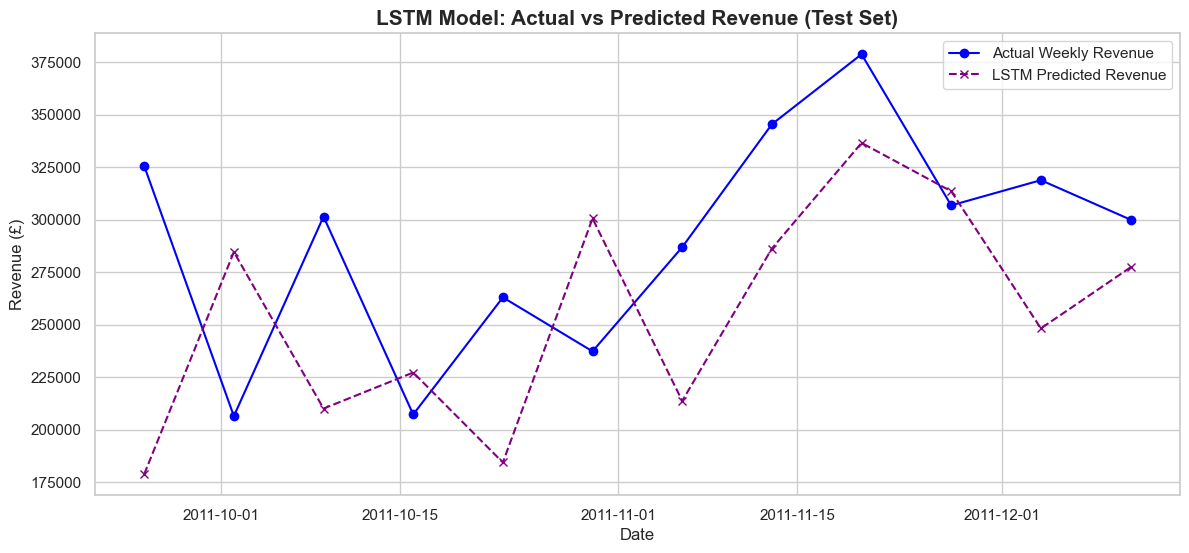

In [43]:
test_dates = weekly_revenue['Date'].iloc[-TEST_SIZE:].values

plt.figure(figsize=(14, 6))
plt.plot(test_dates, actuals, label='Actual Weekly Revenue', marker='o', color='blue')
plt.plot(test_dates, predictions, label='LSTM Predicted Revenue', marker='x', color='purple', linestyle='--')
plt.title('LSTM Model: Actual vs Predicted Revenue (Test Set)', fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.legend()
plt.show()

**Comparing LSTM vs Prophet:**
- **Prophet** is usually better at capturing hard macro-seasonality (like yearly holidays) out-of-the-box.
- **LSTM** is much better at understanding immediate short-term momentum (e.g., if the last 4 weeks were a massive bull run, the LSTM understands that immediate velocity better than Prophet).

## 6. Model & Metrics Persistence
We save the standalone LSTM model, the scaler, and the performance metrics.

In [44]:
# Create models directory
os.makedirs('../models', exist_ok=True)

# 1. Save LSTM Model State
torch.save(model.state_dict(), '../models/standalone_lstm_model_state.pt')

# 2. Save Scaler
joblib.dump(scaler, '../models/standalone_lstm_scaler.joblib')

# 3. Save Metrics
lstm_metrics = {
    'MAE': round(float(mae), 2),
    'RMSE': round(float(rmse), 2),
    'MAPE': round(float(mape), 2)
}

with open('../models/lstm_metrics.json', 'w') as f:
    json.dump(lstm_metrics, f, indent=4)

print("Success: Standalone LSTM model, scaler and metrics saved to '../models/'.")

Success: Standalone LSTM model, scaler and metrics saved to '../models/'.


In [45]:
# Initialize MLflow logger
mlf_logger = MLFlowLogger(
    experiment_name="RetailPulse_Demand_Forecasting",
    run_name="LSTM_Weekly_Forecast",
    tracking_uri="file:./mlruns"
)

# Initialize trainer and attach the MLflow logger
trainer = pl.Trainer(
    max_epochs=150, 
    enable_progress_bar=True, 
    enable_model_summary=False, 
    logger=mlf_logger  
)
trainer.fit(model, train_loader)
print("LSTM metrics successfully logged to MLflow!")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`Trainer.fit` stopped: `max_epochs=150` reached.


LSTM metrics successfully logged to MLflow!
